# Modeling the Invisible Workshop

In [1]:
from google.colab import files
uploaded = files.upload()

Saving release.csv to release.csv


## 1. Settings and data loading

This cell imports packages, sets `RELEASE_FILE = 'release.csv'`, and defines a robust loader that accepts any two-column workshop CSV. The first column is treated as week, and the second column is treated as hospitalizations per 100,000.

For the contest format, keep the input file name as `release.csv`. The output file will be `prediction_release_v7_noisy.csv`.


## Robust handling of noisy releases

This version keeps the active-growth and tail-slowing ideas from v5/v6, but adds a noise-aware preprocessing and weighting layer. The key idea is that the model should not interpret every one-week jump or dip as a true regime change. Instead, it creates a **denoised modeling curve** for fitting the ensemble, while the original released values remain unchanged in the input and final report.

This is especially important when the data are rounded and noisy: a single noisy point can falsely trigger peak-turn, rebound, or explosive-growth logic. The v7 model uses robust smoothing and a median-growth component to reduce those false positives.


In [2]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import least_squares
from scipy.signal import find_peaks, savgol_filter
warnings.filterwarnings('ignore')

# -------------------- User settings --------------------
RELEASE_FILE = 'release.csv'                 # Put the contest release file in the notebook folder with this name.
OUTPUT_FILE = 'prediction_release_v7_noisy.csv'   # Final CSV file to submit.
HORIZON = 5                                  # Contest format: predict the next 5 weeks.
N_POP = 100000
USE_OPTIONAL_TEMPLATES = False               # Keep False if the model should use only release.csv.
NOISE_ROBUST_MODE = True                      # v7: fit components on a denoised modeling trajectory.
PLOT_DENOISED_SIGNAL = True                   # Show smoothed curve in the diagnostic plot.

# -------------------- Data loading --------------------
def resolve_path(filename):
    for folder in [Path.cwd(), Path('/mnt/data')]:
        p = folder / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename}. Put the file in the same folder as this notebook.")

def load_release_csv(path):
    df = pd.read_csv(path, encoding='utf-8-sig')
    if df.shape[1] < 2:
        raise ValueError('The release CSV must have at least two columns: Week and hospitalizations.')
    out = df.iloc[:, :2].copy()
    out.columns = ['Week', 'Hosp']
    out['Week'] = pd.to_numeric(out['Week'], errors='coerce')
    out['Hosp'] = pd.to_numeric(out['Hosp'], errors='coerce')
    out = out.dropna().sort_values('Week').reset_index(drop=True)
    out['Week'] = out['Week'].astype(int)
    out['Hosp'] = out['Hosp'].clip(lower=0)
    return out

# -------------------- Optional template library --------------------
def load_optional_templates():
    templates = {}
    candidates = {
        'CDC_2017': ['influenzaA2017.csv', 'influenzaA2017(1).csv'],
        'CDC_2018': ['influenzaA2018.csv', 'influenzaA2018(1).csv', 'influenzaA2018(2).csv'],
        'Synthetic_extended_SIR': ['SIRCrossover_sample1.csv', 'SIRCrossover_sample1(1).csv']
    }
    for name, names in candidates.items():
        for fn in names:
            try:
                p = resolve_path(fn)
                templates[name] = load_release_csv(p)
                break
            except FileNotFoundError:
                pass
    return templates

## 2. Utility functions and regime detection

These functions compute recent growth, detect unstable spikes, clip impossible forecasts, and protect the model from negative or explosive predictions.

The main growth addition is `active_growth_regime`, and the main decline addition is `sharp_post_peak_decline_regime`: it identifies the situation where the last several weeks are clearly increasing. When this regime is active, the final forecast is not allowed to turn downward unless the data actually show a peak or decline.


In [3]:
# -------------------- Utilities --------------------
def rmse(pred, actual):
    return float(np.sqrt(np.mean((np.asarray(pred, float) - np.asarray(actual, float)) ** 2)))

def safe_log(y, eps=1e-3):
    return np.log(np.maximum(np.asarray(y, float), eps))


def robust_mad(x):
    """Median absolute deviation scaled to a standard-deviation-like value."""
    x = np.asarray(x, float)
    if len(x) == 0:
        return 0.0
    med = np.median(x)
    return float(1.4826 * np.median(np.abs(x - med)) + 1e-8)

def _odd_window(n, target=7):
    """Return a valid odd smoothing window not larger than n."""
    if n < 3:
        return n
    w = min(target, n if n % 2 == 1 else n - 1)
    return max(3, w)

def hampel_filter_log(hosp, window=2, n_sigmas=3.0):
    """
    Robustly replace isolated spikes/dips on the log scale.
    This reduces the chance that one noisy week triggers a false peak or rebound.
    """
    y = np.asarray(hosp, float)
    if len(y) < 5:
        return y.copy(), []
    z = safe_log(y, eps=1e-3)
    zf = z.copy()
    changed = []
    for i in range(len(z)):
        lo = max(0, i - window)
        hi = min(len(z), i + window + 1)
        neigh = np.delete(z[lo:hi], i - lo)
        if len(neigh) < 2:
            continue
        med = np.median(neigh)
        scale = robust_mad(neigh)
        if abs(z[i] - med) > n_sigmas * scale and abs(z[i] - med) > 0.18:
            zf[i] = med
            changed.append(i)
    return np.exp(zf), changed

def savgol_smooth_safe(y, target_window=7, polyorder=2):
    """Savitzky-Golay smoothing with safe fallbacks for short releases."""
    y = np.asarray(y, float)
    n = len(y)
    if n < 5:
        return y.copy()
    w = _odd_window(n, target_window)
    if w <= polyorder:
        return pd.Series(y).rolling(3, center=True, min_periods=1).median().to_numpy()
    try:
        return savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 1), mode='interp')
    except Exception:
        return pd.Series(y).rolling(3, center=True, min_periods=1).median().to_numpy()

def estimate_noise_score(hosp):
    """
    Estimate how noisy/jagged the release looks on the log scale.
    0 means smooth; values near 1 indicate strong short-term jaggedness.
    """
    y = np.asarray(hosp, float)
    if len(y) < 6:
        return 0.0
    z = safe_log(y, eps=1e-3)
    base = savgol_smooth_safe(z, target_window=7, polyorder=2)
    resid = z - base
    resid_level = robust_mad(resid)
    g = np.diff(z)
    g_scale = robust_mad(g)
    if len(g) >= 3:
        sign_flip_rate = np.mean(np.sign(g[1:]) != np.sign(g[:-1]))
    else:
        sign_flip_rate = 0.0
    # Residual-to-growth ratio catches noisy wiggles; sign flips catch jagged alternating data.
    score = 0.65 * (resid_level / (g_scale + 0.08)) + 0.35 * sign_flip_rate
    return float(np.clip(score, 0.0, 1.0))

def smooth_release_for_model(hosp, enabled=True):
    """
    Build the v7 denoised modeling trajectory.

    The returned array is used only for fitting/forecasting. The original release values are
    kept unchanged in the output. Smoothing strength is automatic: smooth releases are barely
    changed, while jagged/noisy releases are smoothed more strongly.
    """
    y = np.asarray(hosp, float)
    if (not enabled) or len(y) < 5:
        return y.copy(), dict(noise_score=0.0, smoothing_alpha=0.0, hampel_points=[])

    y_hampel, idx = hampel_filter_log(y, window=2, n_sigmas=3.0)
    noise = estimate_noise_score(y_hampel)

    z = safe_log(y_hampel, eps=1e-3)
    z_smooth = savgol_smooth_safe(z, target_window=7, polyorder=2)

    # Automatic smoothing strength. Small score => little smoothing; high score => stronger smoothing.
    alpha = float(np.clip(0.10 + 0.60 * noise, 0.10, 0.70))
    if noise < 0.18 and len(idx) == 0:
        alpha = 0.08

    z_model = (1.0 - alpha) * z + alpha * z_smooth

    # Do not fully ignore the latest observation, but reduce its influence when noisy.
    end_keep = float(np.clip(0.80 - 0.45 * noise, 0.35, 0.80))
    z_model[-1] = end_keep * z[-1] + (1.0 - end_keep) * z_model[-1]
    if len(z_model) >= 2:
        z_model[-2] = 0.85 * z[-2] + 0.15 * z_model[-2]

    y_model = np.maximum(np.exp(z_model), 0.0)
    return y_model, dict(noise_score=noise, smoothing_alpha=alpha, hampel_points=idx)

def apply_growth_ceiling(pred, last_obs, max_weekly_growth=1.80):
    """Hard safety cap: no component can grow by more than 80% per week."""
    pred = np.asarray(pred, float)
    prev = max(float(last_obs), 1e-6)
    out = []
    for v in pred:
        v = max(0.0, float(v))
        v = min(v, prev * max_weekly_growth)
        out.append(v)
        prev = max(v, 1e-6)
    return np.asarray(out)

def robust_clip_forecast(pred, observed):
    """Clip impossible or unstable forecasts using only the released data."""
    pred = np.asarray(pred, float)
    obs = np.asarray(observed, float)
    last = max(obs[-1], 1e-6)
    ymax = max(obs.max(), last, 1e-6)
    cap = min(2.2 * ymax, 3.5 * last) + 1.0
    pred = np.nan_to_num(pred, nan=last, posinf=cap, neginf=0.0)
    return np.clip(pred, 0.0, cap)

def active_growth_regime(y):
    """
    v5/v6 detector for the situation that caused the round-2 underprediction.

    It returns True when the most recent data show clear ongoing growth:
      1. last 5 observations are monotonically increasing,
      2. recent median log-growth is positive and substantial,
      3. the current value is much larger than 5 weeks ago,
      4. the latest value is close to the maximum observed so far.

    In this regime, the dangerous error is usually underprediction, not overprediction.
    """
    y = np.asarray(y, float)
    if len(y) < 8:
        return False
    last5 = y[-5:]
    monotone_up = bool(np.all(np.diff(last5) > 0))
    recent_growth = np.diff(safe_log(y[-6:]))
    med_recent_growth = float(np.median(recent_growth)) if len(recent_growth) else 0.0
    strong_total_growth = bool(y[-1] / max(y[-6], 1e-6) > 1.45)
    at_or_near_max = bool(y[-1] >= 0.97 * np.max(y))
    return monotone_up and med_recent_growth > 0.055 and strong_total_growth and at_or_near_max

def apply_active_growth_floor(pred, y, floor_fraction=0.65):
    """
    v5/v6 growth floor. If the released data show active growth, the ensemble forecast
    cannot immediately flatten or decline. The minimum growth rate is a damped
    fraction of the recent median log-growth.
    """
    y = np.asarray(y, float)
    pred = np.asarray(pred, float)
    if not active_growth_regime(y):
        return pred

    recent_log_growth = np.diff(safe_log(y[-6:]))
    g = float(np.median(recent_log_growth)) if len(recent_log_growth) else 0.0
    prev = float(y[-1])
    out = []
    for k, val in enumerate(pred, start=1):
        g_floor = floor_fraction * g * (0.90 ** k)
        min_allowed = prev * np.exp(g_floor)
        val = max(float(val), float(min_allowed))
        out.append(val)
        prev = val
    return np.asarray(out)


def sharp_post_peak_decline_regime(y):
    """
    v6 detector for the situation after a sharp post-peak drop.

    It returns True when the released data show: a previous peak, the current value is
    well below that peak, and the recent weeks are mostly decreasing. In this regime,
    the model should continue declining, but not extrapolate the sharpest decline forever.
    """
    y = np.asarray(y, float)
    if len(y) < 10:
        return False
    peak_idx = int(np.argmax(y))
    has_seen_peak = peak_idx <= len(y) - 3
    below_peak = bool(y[-1] < 0.75 * max(np.max(y), 1e-6))
    recent = y[-5:]
    mostly_down = int(np.sum(np.diff(recent) < 0)) >= 3
    recent_log_growth = np.diff(safe_log(y[-5:]))
    median_decline = float(np.median(recent_log_growth)) if len(recent_log_growth) else 0.0
    sharp_decline = median_decline < -0.10
    total_drop = y[-1] / max(np.max(y), 1e-6) < 0.55
    return bool(has_seen_peak and below_peak and mostly_down and (sharp_decline or total_drop))

def slow_tail_forecast(y, horizon, floor_rt=0.88, relax=0.68):
    """
    v6 slow-tail forecast. It uses the recent decline direction, but relaxes the
    decline multiplier upward toward a floor, so the forecast forms a tail rather
    than collapsing too fast.
    """
    y = np.asarray(y, float)
    recent_g = np.diff(safe_log(y[-5:]))
    g0 = float(np.median(recent_g)) if len(recent_g) else -0.08
    # Convert log-growth to weekly multiplier and prevent unrealistic collapse.
    m0 = float(np.clip(np.exp(g0), 0.55, 0.96))
    prev = float(y[-1])
    out = []
    for k in range(1, horizon + 1):
        # Move from the recent decline multiplier toward the tail floor.
        m = floor_rt + (m0 - floor_rt) * (relax ** k)
        m = float(np.clip(m, floor_rt, 0.98))
        prev *= m
        out.append(prev)
    return np.asarray(out)

def apply_post_peak_tail_slowing(pred, y, blend=0.35):
    """
    v6 tail-slowing correction. It blends the ensemble with a slower-tail decline
    only when a sharp post-peak-decline regime is detected.
    """
    pred = np.asarray(pred, float)
    y = np.asarray(y, float)
    if not sharp_post_peak_decline_regime(y):
        return pred
    tail = slow_tail_forecast(y, len(pred))
    # Do not make the forecast grow; just reduce overly aggressive decline.
    adjusted = (1.0 - blend) * pred + blend * tail
    return np.minimum(np.maximum(adjusted, pred), np.maximum(tail, pred))

def recent_growth_stats(y):
    y = np.asarray(y, float)
    g = np.diff(safe_log(y))
    if len(g) == 0:
        return dict(last_growth=0.0, median_growth=0.0, deceleration=0.0, high_fraction=0.0,
                    n_recent_neg=0, rebound_score=0.0, rebound_active=False, early_rise=False,
                    active_growth=False, sharp_post_peak_decline=False, noise_score=estimate_noise_score(y))
    last = float(g[-1])
    med = float(np.median(g[-min(3, len(g)):]))
    dec = float(max(0.0, np.max(g[-6:-1]) - g[-1])) if len(g) >= 4 else 0.0
    high = float(y[-1] / max(y.max(), 1e-9))
    nneg = int(np.sum(g[-4:] < 0)) if len(g) >= 4 else int(np.sum(g < 0))
    peak_idx = int(np.argmax(y))
    rebound = 0.0
    rebound_active = False
    if peak_idx < len(y) - 4 and y[-1] < 0.98 * y.max():
        trough = np.min(y[peak_idx:])
        recover = (y[-1] - trough) / max(y.max(), 1e-6)
        rebound = max(0.0, med) * max(0.0, recover) * 2.0
        rebound_active = bool(rebound > 0.03 and med > 0.02)
    early_rise = bool(len(y) <= 12 and y[-1] == y.max() and med > 0.06 and nneg == 0)
    active = active_growth_regime(y)
    sharp_decline = sharp_post_peak_decline_regime(y)
    noise_score = estimate_noise_score(y)
    return dict(last_growth=last, median_growth=med, deceleration=dec, high_fraction=high,
                n_recent_neg=nneg, rebound_score=float(rebound), rebound_active=rebound_active,
                early_rise=early_rise, active_growth=active,
                sharp_post_peak_decline=sharp_decline, noise_score=noise_score)

def detect_spikes(hosp, z_thresh=3.0):
    y = np.asarray(hosp, float)
    if len(y) < 4:
        return []
    min_val = max(y.max() * 0.05, 1e-9)
    lr = np.diff(np.log(np.maximum(y, 0.01)))
    med = np.median(lr)
    mad = np.median(np.abs(lr - med)) + 1e-6
    z = np.abs(lr - med) / (1.4826 * mad)
    return [int(i + 1) for i in np.where(z > z_thresh)[0] if y[i + 1] > min_val and y[i] > min_val]

def smooth_for_fitting(hosp, idx):
    y = np.asarray(hosp, float).copy()
    for i in idx:
        if 0 < i < len(y) - 1:
            y[i] = (y[i - 1] + y[i + 1]) / 2
    return y


## 3. Forecasting components

Important behavior:

- `early_growth_wave` is used not only in the first 10 weeks, but also in later monotone growth phases.
- `damped_growth` damps less aggressively during active growth.
- `logquad_peak_turn` is blocked from forcing a decline while `active_growth=True`.
- `rebound_wave` can act as a growth-supporting component when the data are rising again.


In [4]:
# -------------------- Forecast components --------------------
def component_last_value(weeks, y, h):
    return np.full(h, float(y[-1]))

def component_damped_growth(weeks, y, h):
    s = recent_growth_stats(y)
    g0 = s['median_growth']
    dec = s['deceleration']
    curr = float(y[-1])
    out = []
    for k in range(1, h + 1):
        # v5: during active growth, damp less aggressively.
        if s['active_growth']:
            damp = 0.88
            dec_penalty = 0.05
        elif s['early_rise']:
            damp = 0.82
            dec_penalty = 0.12
        else:
            damp = 0.58
            dec_penalty = 0.18
        gk = g0 * (damp ** k) - dec_penalty * dec * k
        if s['rebound_score'] > 0.03 and g0 > 0:
            gk = max(gk, min(g0 * (0.76 ** k), 0.35))
        gk = float(np.clip(gk, -0.65, 0.55))
        curr *= np.exp(gk)
        out.append(curr)
    return apply_growth_ceiling(out, y[-1])


def component_robust_median_trend(weeks, y, h):
    """
    v7 noisy-data component: use the median recent log-growth rather than a least-squares
    slope. This is less sensitive to a single noisy spike or dip.
    """
    y = np.asarray(y, float)
    n = len(y)
    w = min(8, n)
    g = np.diff(safe_log(y[-w:]))
    if len(g) == 0:
        return np.full(h, float(y[-1]))
    g_med = float(np.median(g))
    g_mad = robust_mad(g)
    # Shrink noisy growth estimates toward zero.
    noise = estimate_noise_score(y)
    g0 = g_med * (1.0 - 0.45 * noise)
    g0 = float(np.clip(g0, -0.45, 0.45))
    prev = float(y[-1])
    out = []
    for k in range(1, h + 1):
        # Gradually damp the trend; use MAD to avoid overconfidence in noisy data.
        gk = g0 * (0.82 ** k)
        if abs(gk) < 0.25 * g_mad:
            gk *= 0.75
        prev *= np.exp(gk)
        out.append(prev)
    return apply_growth_ceiling(out, y[-1])

def component_loglinear(weeks, y, h, window=6):
    n = len(y)
    w = min(window, n)
    x = np.arange(n - w, n)
    z = safe_log(y[-w:])
    b, a = np.polyfit(x, z, 1)
    # v5: allow moderately strong growth when the data clearly support it.
    upper = 0.55 if active_growth_regime(y) else 0.45
    b = float(np.clip(b, -0.55, upper))
    fx = np.arange(n, n + h)
    return apply_growth_ceiling(np.exp(a + b * fx), y[-1])

def component_logquad_peak_turn(weeks, y, h):
    n = len(y)
    cands = []
    for win in [4, 5, 6]:
        if n >= win:
            x = np.arange(n - win, n)
            z = safe_log(y[-win:])
            coef = np.polyfit(x, z, 2)
            if coef[0] > 0:
                coef[0] *= 0.05
            cands.append(np.exp(np.polyval(coef, np.arange(n, n + h))))
    pred = np.median(cands, axis=0) if cands else component_loglinear(weeks, y, h)
    s = recent_growth_stats(y)
    peak_risk = s['high_fraction'] * max(0.0, s['deceleration']) * max(0.0, s['last_growth'] + 0.10)
    atmax = y[-1] >= 0.98 * np.max(y)
    mostly_down = s['n_recent_neg'] >= 3
    # v5: do not impose a peak-turn decline if the active-growth detector is on.
    if (not s['early_rise']) and (not s['active_growth']) and (peak_risk > 0.12 or (atmax and s['deceleration'] > 0.25) or mostly_down):
        mild = np.array([0.98, 0.88, 0.78, 0.68, 0.60, 0.54, 0.49, 0.45])[:h]
        sharp = np.array([0.92, 0.70, 0.54, 0.45, 0.38, 0.32, 0.28, 0.25])[:h]
        sharpness = float(np.clip(s['deceleration'] / 0.80, 0.0, 1.0))
        factors = (1 - sharpness) * mild + sharpness * sharp
        turn = y[-1] * factors
        alpha = 0.94 if atmax else min(0.90, 0.55 + peak_risk)
        pred = alpha * turn + (1 - alpha) * pred
    return apply_growth_ceiling(pred, y[-1])

def component_sqrt_cubic(weeks, y, h):
    n = len(y)
    win = min(n, 8)
    x = np.arange(n - win, n)
    z = np.sqrt(np.maximum(y[-win:], 0.0))
    deg = min(3, win - 1)
    w = np.linspace(0.6, 1.0, win)
    coef = np.polyfit(x - x[-1], z, deg, w=w)
    pred = np.maximum(np.polyval(coef, np.arange(1, h + 1)), 0.0) ** 2
    return apply_growth_ceiling(pred, y[-1])

def component_early_growth_wave(weeks, y, h):
    """Monotone active-growth component. Useful both in early rounds and later second-growth rounds."""
    y = np.asarray(y, float)
    g = np.diff(safe_log(y[-min(len(y), 6):]))
    g0 = float(np.median(g[-3:])) if len(g) else 0.08
    # v5: if active growth is clearly ongoing, keep a stronger but damped trajectory.
    if active_growth_regime(y):
        g0 = float(np.clip(g0, 0.08, 0.30))
        damp = 0.88
    else:
        g0 = float(np.clip(g0, 0.05, 0.32))
        damp = 0.90
    curr = float(y[-1])
    out = []
    for k in range(1, h + 1):
        gk = g0 * (damp ** (k - 1))
        curr *= np.exp(gk)
        out.append(curr)
    return apply_growth_ceiling(out, y[-1])

def component_rebound_wave(weeks, y, h):
    s = recent_growth_stats(y)
    # v5: active growth after many weeks is treated as a possible second infectious agent / wave.
    if s.get('active_growth', False):
        y = np.asarray(y, float)
        g = np.diff(safe_log(y[-6:]))
        g0 = float(np.median(g[-4:])) if len(g) else 0.08
        g0 = float(np.clip(g0, 0.07, 0.28))
        curr = float(y[-1])
        out = []
        for k in range(1, h + 1):
            gk = g0 * (0.86 ** (k - 1))
            curr *= np.exp(gk)
            out.append(curr)
        return apply_growth_ceiling(out, y[-1])
    if s.get('early_rise', False):
        return component_early_growth_wave(weeks, y, h)
    if not s.get('rebound_active', False):
        return component_damped_growth(weeks, y, h)
    y = np.asarray(y, float)
    g = np.diff(safe_log(y[-5:])) if len(y) >= 5 else np.diff(safe_log(y))
    g0 = float(np.median(g[-3:])) if len(g) > 0 else 0.05
    g0 = float(np.clip(g0, 0.04, 0.30))
    curr = float(y[-1])
    cap = min(max(curr * 1.65, y.max() * 1.65), curr + 4.0)
    out = []
    for k in range(1, h + 1):
        gk = g0 * (0.80 ** (k - 1))
        curr *= np.exp(gk)
        curr = min(curr, cap)
        out.append(curr)
    return apply_growth_ceiling(out, y[-1])

def component_analog_templates(weeks, y, h, template_library=None):
    if not template_library:
        return component_last_value(weeks, y, h)
    n = len(y)
    y = np.asarray(y, float)
    scale = max(y.max(), y[-1], 1e-3)
    y_norm = y / scale
    matches = []
    for name, df in template_library.items():
        ty = df['Hosp'].to_numpy(float)
        if len(ty) < n + h:
            continue
        for start in range(0, len(ty) - n - h + 1):
            seg = ty[start:start + n]
            seg_scale = max(seg.max(), seg[-1], 1e-3)
            seg_norm = seg / seg_scale
            ww = np.linspace(0.4, 1.0, n)
            dist = float(np.sqrt(np.mean(ww * (seg_norm - y_norm) ** 2)))
            if n >= 4:
                gy = np.diff(safe_log(y[-4:]))
                gs = np.diff(safe_log(seg[-4:]))
                dist += 0.20 * float(np.sqrt(np.mean((gy - gs) ** 2)))
            future = ty[start + n:start + n + h] * scale / seg_scale
            matches.append((dist, future))
    if not matches:
        return component_last_value(weeks, y, h)
    matches = sorted(matches, key=lambda x: x[0])[:8]
    d = np.array([m[0] for m in matches])
    W = np.exp(-d / (np.median(d) + 1e-6))
    W /= W.sum()
    pred = np.sum([W[i] * matches[i][1] for i in range(len(matches))], axis=0)
    return apply_growth_ceiling(pred, y[-1])


## 4. SIR component and weekly reproduction-number output

The notebook fits a lightweight SIR component. The contest output column is named `r0`; because the requested value is week-by-week, this notebook fills `r0` using the SIR-based effective reproduction estimate for the forecast weeks. It also guards against unstable SIR fits on very short releases by falling back to a smoothed growth proxy if needed.

In [5]:
# -------------------- SIR component and R calculation --------------------
_sir_cache = {}

def _sir_ode(state, t, R0, gamma, N):
    S, I, R = state
    beta = R0 * gamma
    new = beta * S * I / N
    return [-new, new - gamma * I, gamma * I]

def run_sir_params(params, N, n_weeks):
    R0, gamma, I0, hf = params
    days = int(n_weeks * 7)
    t = np.linspace(0, days, days + 1)
    sol = odeint(_sir_ode, [N - I0, I0, 0.0], t, args=(R0, gamma, N), mxstep=3000)
    S = sol[:, 0]
    beta = R0 * gamma
    new = beta * S * sol[:, 1] / N
    weekly = np.array([np.sum(new[w * 7:(w + 1) * 7]) for w in range(n_weeks)]) / N * 100000 * hf
    Rt = R0 * (S[::7][:n_weeks] / N)
    return weekly, Rt, S

def fit_sir_single_fast(observed, N=N_POP, horizon=HORIZON):
    obs = np.asarray(observed, float)
    n = len(obs)
    n_total = n + horizon
    key = ('sir1', tuple(np.round(obs, 5)), n_total)
    if key in _sir_cache:
        return _sir_cache[key]
    def resid(p):
        return run_sir_params(p, N, n)[0] - obs
    bounds = ([1.001, 0.04, 1.0, 1e-5], [5.0, 0.9, N * 0.05, 1.0])
    ymax = max(obs.max(), 1e-6)
    starts = []
    for R0 in [1.15, 1.5, 2.0, 2.8, 3.8]:
        for gamma in [0.08, 0.18, 0.35]:
            starts.append([R0, gamma, 50, min(0.25, max(1e-4, ymax / 5000))])
    best = None
    bestcost = 1e18
    for x0 in starts:
        try:
            r = least_squares(resid, x0, bounds=bounds, max_nfev=150, xtol=1e-4, ftol=1e-4, gtol=1e-4)
            if r.cost < bestcost:
                bestcost = float(r.cost)
                best = r.x
        except Exception:
            pass
    if best is None:
        best = np.array([1.5, 0.2, 50, 0.01])
    weekly, Rt, S = run_sir_params(best, N, n_total)
    fit = rmse(weekly[:n], obs)
    _sir_cache[key] = (weekly, Rt, fit, 1, best)
    return _sir_cache[key]

def component_sir_mechanistic(weeks, y, h, N=N_POP):
    y_s = smooth_for_fitting(y, detect_spikes(y))
    full, Rt, fit, n_waves, params = fit_sir_single_fast(y_s, N, h)
    n = len(y)
    pred = apply_growth_ceiling(full[n:n + h], y[-1])
    return pred, full, Rt, fit, n_waves, params

## 5. Adaptive ensemble and submission writer

The adaptive weights include a new active-growth override. If the last several weeks show strong monotone growth, the model increases the influence of growth components and decreases the influence of peak-turn/flat components.

The final point forecast is also passed through `apply_active_growth_floor`, which prevents the ensemble from forecasting a decline while the released data are clearly rising.


In [6]:
# -------------------- Ensemble --------------------
COMPONENT_NAMES = [
    'last_value', 'damped_growth', 'loglinear', 'logquad_peak_turn',
    'sqrt_cubic', 'robust_median_trend', 'early_growth_wave', 'rebound_wave', 'analog_templates', 'sir_mechanistic'
]

def make_component_predictions(weeks, y, h, template_library=None, N=N_POP):
    raw = {
        'last_value': component_last_value(weeks, y, h),
        'damped_growth': component_damped_growth(weeks, y, h),
        'loglinear': component_loglinear(weeks, y, h),
        'logquad_peak_turn': component_logquad_peak_turn(weeks, y, h),
        'sqrt_cubic': component_sqrt_cubic(weeks, y, h),
        'robust_median_trend': component_robust_median_trend(weeks, y, h),
        'early_growth_wave': component_early_growth_wave(weeks, y, h),
        'rebound_wave': component_rebound_wave(weeks, y, h),
        'analog_templates': component_analog_templates(weeks, y, h, template_library),
    }
    sir_pred, sir_full, sir_rt, sir_fit, n_waves, sir_params = component_sir_mechanistic(weeks, y, h, N)
    raw['sir_mechanistic'] = sir_pred
    comps = {k: robust_clip_forecast(v, y) for k, v in raw.items()}
    return comps, sir_full, sir_rt, sir_fit, n_waves, sir_params

def adaptive_component_weights(weeks, y, h, comps, sir_fit=None, noise_score=0.0):
    y = np.asarray(y, float)
    s = recent_growth_stats(y)
    weights = {name: 1.0 for name in COMPONENT_NAMES}

    # Default safety preferences.
    weights['last_value'] *= 0.7
    weights['logquad_peak_turn'] *= 1.2
    weights['sir_mechanistic'] *= 1.2
    weights['analog_templates'] *= 0.7
    weights['robust_median_trend'] *= 1.4

    # Early monotone growth, usually release 1.
    if s['early_rise']:
        weights['early_growth_wave'] *= 5.0
        weights['damped_growth'] *= 3.0
        weights['loglinear'] *= 2.5
        weights['sqrt_cubic'] *= 1.6
        weights['logquad_peak_turn'] *= 0.45
        weights['last_value'] *= 0.35
        weights['sir_mechanistic'] *= 1.0

    # v5/v6 active growth, designed for the round-3 situation after weeks 16--20 rose quickly.
    if s['active_growth']:
        weights['early_growth_wave'] *= 4.0
        weights['loglinear'] *= 2.5
        weights['damped_growth'] *= 2.0
        weights['rebound_wave'] *= 2.0
        weights['sqrt_cubic'] *= 1.3
        weights['logquad_peak_turn'] *= 0.25
        weights['sir_mechanistic'] *= 0.60
        weights['last_value'] *= 0.40
        weights['analog_templates'] *= 0.60

    # Rebound/second-wave case with observed first peak, trough, and renewed growth.
    if s['rebound_active']:
        weights['rebound_wave'] *= 5.0
        weights['damped_growth'] *= 2.5
        weights['loglinear'] *= 1.7
        weights['logquad_peak_turn'] *= 0.5
        weights['last_value'] *= 0.4

    # Post-peak decline.
    if s['n_recent_neg'] >= 3:
        weights['damped_growth'] *= 2.5
        weights['logquad_peak_turn'] *= 2.0
        weights['early_growth_wave'] *= 0.3
        weights['loglinear'] *= 0.5

    # v6: after a sharp drop, keep decline but avoid over-extrapolating collapse.
    if s.get('sharp_post_peak_decline', False):
        weights['damped_growth'] *= 1.4
        weights['logquad_peak_turn'] *= 1.2
        weights['last_value'] *= 1.5
        weights['sir_mechanistic'] *= 1.25
        weights['early_growth_wave'] *= 0.15
        weights['loglinear'] *= 0.45
        weights['rebound_wave'] *= 0.35



    # v7: when the release is noisy, reduce very reactive curve-fit components and
    # boost robust/conservative components. The components are already fit on a denoised
    # signal, but this extra weighting prevents overreaction to noisy one-week wiggles.
    if noise_score > 0.20:
        weights['robust_median_trend'] *= (1.0 + 2.0 * noise_score)
        weights['damped_growth'] *= (1.0 + 1.2 * noise_score)
        weights['last_value'] *= (1.0 + 1.0 * noise_score)
        weights['sir_mechanistic'] *= (1.0 + 0.8 * noise_score)
        weights['analog_templates'] *= (1.0 + 0.6 * noise_score)
        weights['loglinear'] *= max(0.35, 1.0 - 0.55 * noise_score)
        weights['sqrt_cubic'] *= max(0.45, 1.0 - 0.45 * noise_score)
        weights['early_growth_wave'] *= max(0.45, 1.0 - 0.40 * noise_score)
        weights['rebound_wave'] *= max(0.45, 1.0 - 0.40 * noise_score)

    # If SIR fit is poor on the released data, reduce its influence.
    if sir_fit is not None:
        scale = max(0.1, np.std(y[-min(len(y), 6):]))
        if sir_fit > 1.5 * scale + 0.3:
            weights['sir_mechanistic'] *= 0.4
    total = sum(weights.values())
    return {k: weights[k] / total for k in COMPONENT_NAMES}

def r0_values_for_output(details, released, horizon):
    # The requested file calls the column r0. Since it asks for a week-by-week value,
    # we report the SIR-based effective reproduction number estimate for each forecast week.
    rt = np.asarray(details['sir_rt'], float)
    n = len(released)
    if len(rt) < n + horizon:
        rt = np.pad(rt, (0, n + horizon - len(rt)), mode='edge')
    rvals = rt[n:n + horizon].copy()

    # Guard against unstable SIR values by blending with a growth proxy.
    y_raw = released['Hosp'].to_numpy(float)
    y = np.asarray(details.get('y_model', y_raw), float)
    g = np.diff(safe_log(y[-min(len(y), 6):]))
    growth_proxy = np.exp(float(np.median(g[-4:]))) if len(g) else 1.0
    growth_proxy = float(np.clip(growth_proxy, 0.3, 4.5))
    if np.any(~np.isfinite(rvals)) or np.mean(rvals) < 0.2 or np.mean(rvals) > 8:
        rvals = np.array([1 + (growth_proxy - 1) * (0.9 ** k) for k in range(horizon)])

    # v5: if the released data are in active growth, do not submit r0/Rt below 1.
    if active_growth_regime(y):
        r_floor = np.array([1.08 + 0.02 * (0.85 ** k) for k in range(horizon)])
        rvals = np.maximum(rvals, r_floor)

    # v6: after a sharp post-peak decline, allow Rt/r0 below 1 but do not let it
    # collapse too low; this gives a slower, more realistic tail.
    if sharp_post_peak_decline_regime(y):
        tail_floor = np.array([0.92 - 0.01 * min(k, 4) for k in range(horizon)])
        rvals = np.maximum(rvals, tail_floor)
    return np.round(np.clip(rvals, 0.05, 9.99), 4)

def competitive_forecast_release(released, horizon=HORIZON, template_library=None, N=N_POP):
    weeks = released['Week'].to_numpy(float)
    y_raw = released['Hosp'].to_numpy(float)

    # v7: fit on a denoised modeling trajectory, not directly on the noisy release.
    y_model, noise_info = smooth_release_for_model(y_raw, enabled=NOISE_ROBUST_MODE)

    comps, sir_full, sir_rt, sir_fit, n_waves, sir_params = make_component_predictions(weeks, y_model, horizon, template_library, N)
    weights = adaptive_component_weights(weeks, y_model, horizon, comps, sir_fit=sir_fit,
                                         noise_score=noise_info.get('noise_score', 0.0))
    point = np.sum([weights[k] * comps[k] for k in COMPONENT_NAMES], axis=0)
    st = recent_growth_stats(y_model)

    if st['early_rise']:
        # Extra blend toward the early-growth component for release-1-like monotone growth.
        point = 0.75 * point + 0.25 * comps['early_growth_wave']
    if st['rebound_active']:
        point = 0.70 * point + 0.30 * comps['rebound_wave']
    if st['active_growth']:
        # Growth-aware blend and floor when the smoothed curve is still rising strongly.
        point = 0.50 * point + 0.25 * comps['early_growth_wave'] + 0.15 * comps['rebound_wave'] + 0.10 * comps['robust_median_trend']
        point = apply_active_growth_floor(point, y_model, floor_fraction=0.60)

    # Anchor the model forecast back to the current observation scale, but avoid following
    # a noisy last point too strongly when the noise score is high.
    noise_score = noise_info.get('noise_score', 0.0)
    raw_weight = float(np.clip(0.80 - 0.45 * noise_score, 0.35, 0.80))
    current_anchor = raw_weight * y_raw[-1] + (1.0 - raw_weight) * y_model[-1]
    scale = current_anchor / max(y_model[-1], 1e-6)
    point = point * scale

    point = apply_growth_ceiling(robust_clip_forecast(point, y_raw), current_anchor)
    point = apply_active_growth_floor(point, y_model, floor_fraction=0.60)

    # Tail slowing should be determined from the denoised modeling signal, then clipped to raw scale.
    point = apply_post_peak_tail_slowing(point, y_model, blend=0.40)
    point = robust_clip_forecast(point, y_raw)

    # Merge diagnostics.
    st = dict(st)
    st.update(noise_info)
    return dict(forecast=point, weights=weights, components=comps, stats=st, sir_full=sir_full,
                sir_rt=sir_rt, sir_fit_rmse=sir_fit, sir_n_waves=n_waves, sir_params=sir_params,
                y_model=y_model, y_raw=y_raw, noise_info=noise_info)

def make_release_prediction(release_csv_path=RELEASE_FILE, output_csv_path=OUTPUT_FILE, horizon=HORIZON):
    released = load_release_csv(resolve_path(release_csv_path))
    template_library = load_optional_templates() if USE_OPTIONAL_TEMPLATES else {}
    details = competitive_forecast_release(released, horizon=horizon, template_library=template_library)
    last_week = int(released['Week'].iloc[-1])
    future_weeks = np.arange(last_week + 1, last_week + 1 + horizon)
    r0_vals = r0_values_for_output(details, released, horizon)
    pred_df = pd.DataFrame({
        'Week': future_weeks.astype(int),
        'Hospitalizations_per_100K': np.round(details['forecast'], 4),
        'r0': r0_vals
    })
    pred_df.to_csv(output_csv_path, index=False)
    return pred_df, released, details


In [7]:
prediction, released, details = make_release_prediction(RELEASE_FILE, OUTPUT_FILE, HORIZON)
print(f'Loaded {len(released)} observed weeks from {RELEASE_FILE}')
print(f'Saved prediction to {OUTPUT_FILE}')
print('\nPrediction file:')
print(prediction.to_string(index=False))
print('\nTop component weights:')
for k, v in sorted(details['weights'].items(), key=lambda kv: -kv[1])[:6]:
    print(f'  {k:22s} {100*v:6.2f}%')
print('\nRegime diagnostics:', details['stats'])

Loaded 13 observed weeks from release.csv
Saved prediction to prediction_release_v7_noisy.csv

Prediction file:
 Week  Hospitalizations_per_100K     r0
   13                    36.5718 1.8213
   14                    51.8748 1.6716
   15                    51.8748 1.4652
   16                    51.8748 1.2270
   17                    51.8748 1.0904

Top component weights:
  early_growth_wave       21.03%
  damped_growth           19.23%
  robust_median_trend     16.51%
  loglinear               12.12%
  rebound_wave            10.52%
  sqrt_cubic               6.66%

Regime diagnostics: {'last_growth': 0.48613145916133815, 'median_growth': 1.2587686898138977, 'deceleration': 0.873527039836729, 'high_fraction': 1.0, 'n_recent_neg': 0, 'rebound_score': 0.0, 'rebound_active': False, 'early_rise': False, 'active_growth': True, 'sharp_post_peak_decline': False, 'noise_score': 0.4290231510915816, 'smoothing_alpha': 0.357413890654949, 'hampel_points': [3]}


## 7. Diagnostic plot

This plot shows the released data and the model forecast. Since this is a live contest release, there is no held-out future truth available yet.

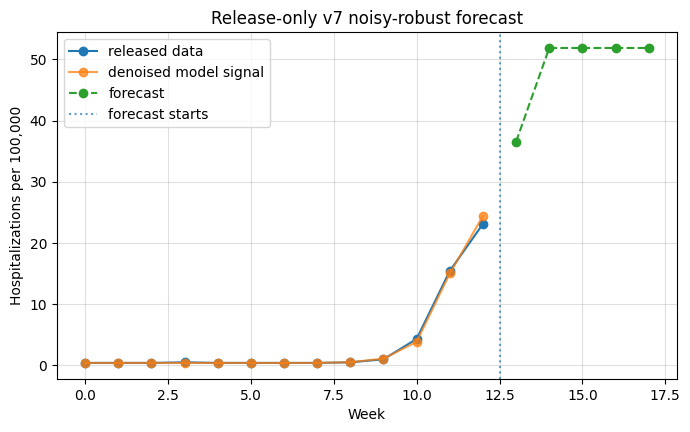

In [8]:

plt.figure(figsize=(8,4.5))
plt.plot(released['Week'], released['Hosp'], 'o-', label='released data')
if PLOT_DENOISED_SIGNAL and 'y_model' in details:
    plt.plot(released['Week'], details['y_model'], 'o-', alpha=0.75, label='denoised model signal')
plt.plot(prediction['Week'], prediction['Hospitalizations_per_100K'], 'o--', label='forecast')
plt.axvline(released['Week'].iloc[-1] + 0.5, linestyle=':', alpha=0.7, label='forecast starts')
plt.xlabel('Week')
plt.ylabel('Hospitalizations per 100,000')
plt.title('Release-only v7 noisy-robust forecast')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()
